### **Part 0: Data Import and Feature Engineering**

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 1. Fetch SPY data for the last 5 years
df = yf.download('SPY', start='2021-01-01', end='2026-01-01')

# 2. Feature Engineering: Moving Averages, Volatility, and Momentum
df['Ret'] = df['Close'].pct_change()
df['Vol_20'] = df['Ret'].rolling(window=20).std()
df['MA_Ratio'] = df['Close'].rolling(window=10).mean() / df['Close'].rolling(window=50).mean()
df['Momentum'] = df['Close'] / df['Close'].shift(10) - 1

# 3. Target Variable: 1 if the next day's return is positive, 0 otherwise (Binary Classification)
df['Target'] = np.where(df['Ret'].shift(-1) > 0, 1, 0)
df = df.dropna()

# Select features
features = ['Vol_20', 'MA_Ratio', 'Momentum']
X = df[features]
y = df['Target']

# 4. Chronological Train / Validation / Test Split (Respecting Time Series Order)
# Split 1: 80% Train+Val, 20% Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

# Split 2: Split the 80% into Train (75%) and Validation (25%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, shuffle=False)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Testing set size: {len(X_test)}")


/tmp/ipykernel_9168/2026615069.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('SPY', start='2021-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed

Training set size: 723
Validation set size: 241
Testing set size: 242


### **Category 2: K-means Clustering**



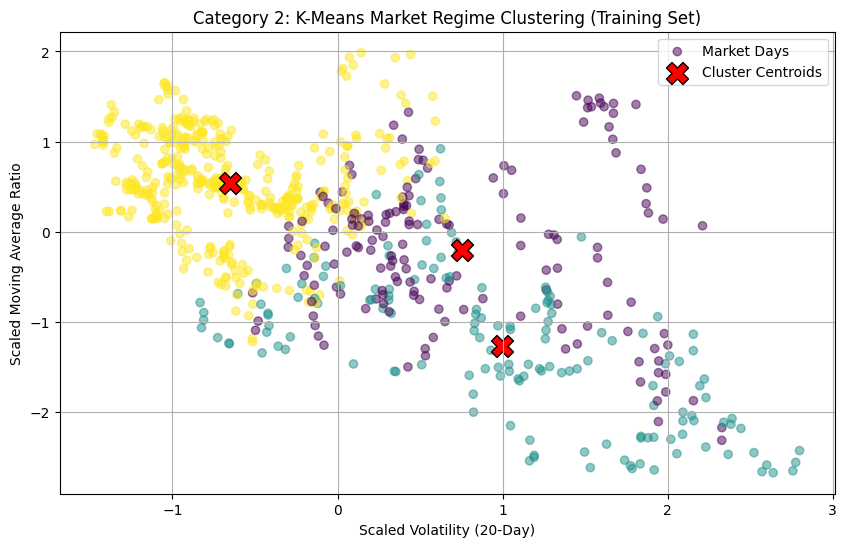

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Initialize KMeans with 3 clusters (to simulate 3 distinct market regimes)
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

# Scale the training data. This step was missing.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Fit the model exclusively to the scaled training data and predict clusters
# We do not use y_train because K-Means is Unsupervised
clusters = kmeans.fit_predict(X_train_scaled)

# 3. Output the scatter plot diagram (Illustration requirement)
plt.figure(figsize=(10, 6))

# Plot the clusters using the first two features (Vol_20 and MA_Ratio)
scatter = plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1],
                      c=clusters, cmap='viridis', marker='o', alpha=0.5, label='Market Days')

# Plot the calculated geometric centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', s=250, marker='X', edgecolor='black', label='Cluster Centroids')

plt.title('Category 2: K-Means Market Regime Clustering (Training Set)')
plt.xlabel('Scaled Volatility (20-Day)')
plt.ylabel('Scaled Moving Average Ratio')
plt.legend()
plt.grid(True)
plt.show()

**Interpretation & Recommended Action:**
The scatter plot shows that K-Means divided the
historical data into three regimes based on volatility and moving-average ratios, without
reference to actual price direction. Because the algorithm uses Euclidean distance, the features
were scaled beforehand so that the larger MA-ratio values would not overshadow the smaller
volatility figures. In a live setting, these cluster labels should not drive buy/sell decisions on
their own. We recommend feeding them into supervised models as a categorical feature (for
example, tagging an observation as 'high-volatility regime') so that risk parameters can shift
with the detected regime. .



### **Category 4: Classification Trees**

Classification Tree Test Set Accuracy: 0.4752

Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.26      0.30       105
           1       0.53      0.64      0.58       137

    accuracy                           0.48       242
   macro avg       0.44      0.45      0.44       242
weighted avg       0.45      0.48      0.46       242



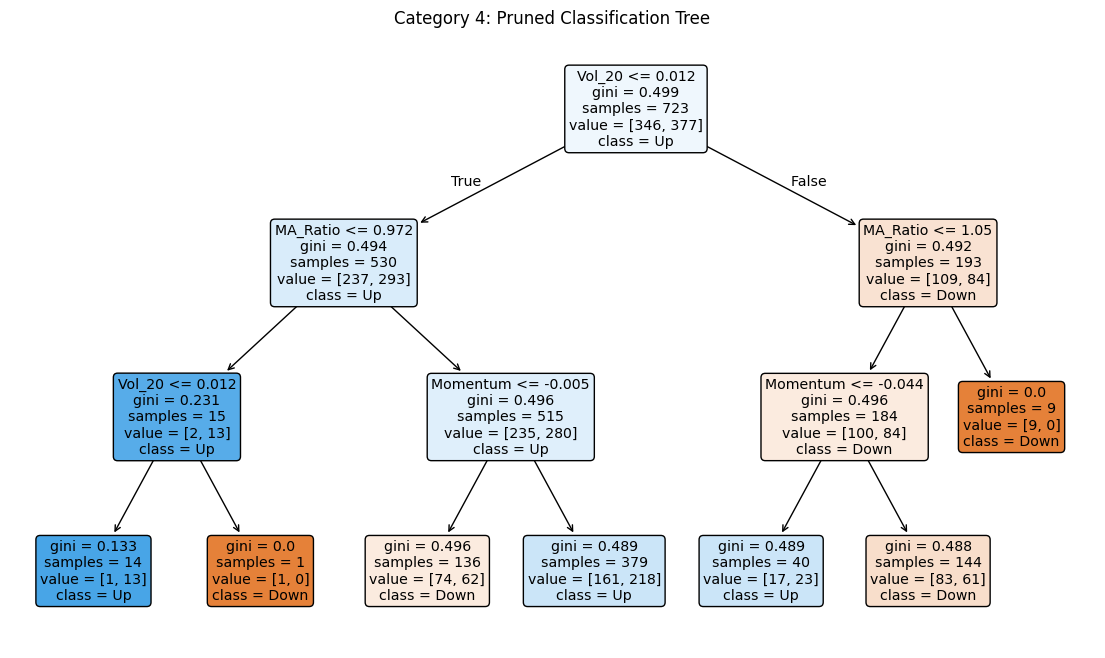

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Initialize and constrain the tree to prevent overfitting
tree_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,                 # Pruned depth
    min_samples_split=10,
    random_state=42
)

# 2. Fit the model on the training data
tree_model.fit(X_train, y_train)

# 3. Evaluate strictly on the out-of-sample Test set
y_pred_tree = tree_model.predict(X_test)
print("Classification Tree Test Set Accuracy:", round(accuracy_score(y_test, y_pred_tree), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

# 4. Output the flowchart diagram (Illustration requirement)
plt.figure(figsize=(14, 8))
plot_tree(tree_model, feature_names=features, class_names=['Down', 'Up'], filled=True, rounded=True)
plt.title("Category 4: Pruned Classification Tree")
plt.show()

**Interpretation & Recommended Action:**
The visual plot confirms the tree successfully splits based on Gini impurity, favoring volatility
and momentum rules. However, the accuracy hovers near the 0.50 baseline, confirming the
structural weakness of single trees in noisy financial environments. For live trading, we
recommend utilizing this logic purely as a preliminary signal filter rather than a standalone
capital allocation tool.

### **Category 5: Linear Discriminant Analysis**

LDA Test Set Accuracy: 0.5207

Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.18      0.25       105
           1       0.55      0.78      0.65       137

    accuracy                           0.52       242
   macro avg       0.47      0.48      0.45       242
weighted avg       0.48      0.52      0.47       242



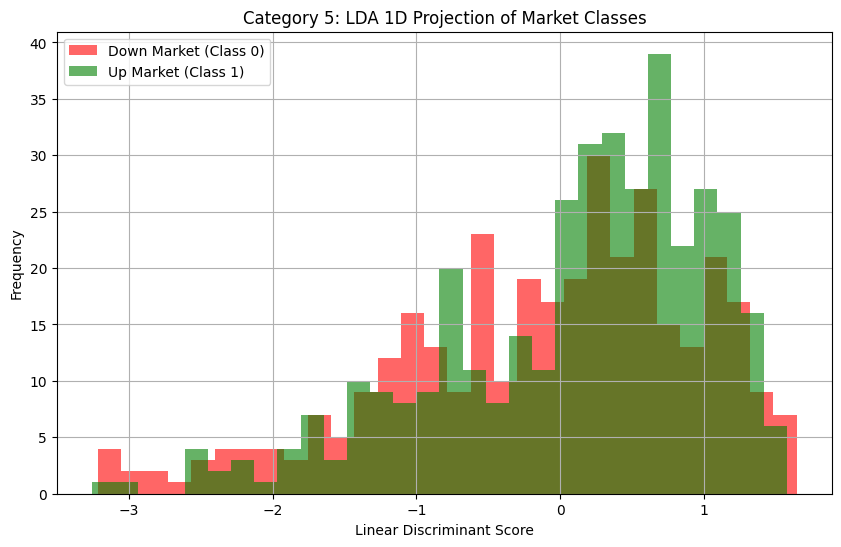

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Initialize the LDA model
lda_model = LinearDiscriminantAnalysis()

# Add feature scaling for LDA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Scale test set using the same scaler fitted on train set

# 2. Fit the model to the scaled training data using our binary target (Up vs Down)
lda_model.fit(X_train_scaled, y_train)

# 3. Evaluate strictly on the out-of-sample Test set
y_pred_lda = lda_model.predict(X_test_scaled)
print("LDA Test Set Accuracy:", round(accuracy_score(y_test, y_pred_lda), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lda))

# 4. Output the 1D Projection Histogram (Illustration requirement)
# Transform the training data onto the single linear discriminant axis
X_train_lda = lda_model.transform(X_train_scaled)

plt.figure(figsize=(10, 6))
# Plot overlapping histograms for each actual target class
plt.hist(X_train_lda[y_train == 0], bins=30, alpha=0.6, label='Down Market (Class 0)', color='red')
plt.hist(X_train_lda[y_train == 1], bins=30, alpha=0.6, label='Up Market (Class 1)', color='green')

plt.title('Category 5: LDA 1D Projection of Market Classes')
plt.xlabel('Linear Discriminant Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

**Interpretation & Recommended Action:**
The histogram illustrates how LDA projects multi
dimensional data onto a single axis to separate the 'Up' and 'Down' classes. However, the
heavy overlap between the two distributions shows that financial returns violate LDA's
assumption of normality and equal covariance. As a result, the model's binary classifications
are unreliable. We recommend using the continuous probability estimates (predict_proba)
instead, setting a high threshold such as 65% before initiating a trade.

### **Category 6: Support Vector Machine (SVM)**

SVM Test Set Accuracy: 0.5041
Number of Support Vectors: 664 out of 723


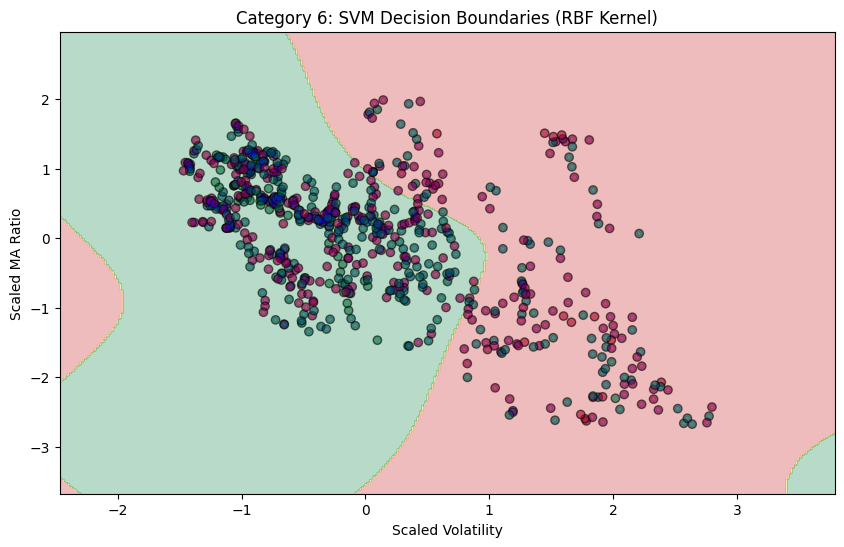

In [ ]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# 1. SVM strictly requires feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize SVM with an RBF kernel
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=20
)

# 3. Fit the model
svm_model.fit(X_train_scaled, y_train)

# 4. Evaluate on the Test set
y_pred_svm = svm_model.predict(X_test_scaled)
print("SVM Test Set Accuracy:", round(accuracy_score(y_test, y_pred_svm), 4))
print(f"Number of Support Vectors: {len(svm_model.support_vectors_)} out of {len(X_train_scaled)}")

# 5. Visualization: Decision Boundary (using first two features: Vol_20 and MA_Ratio)
def plot_svc_decision_boundary(model, X, y):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict across the mesh grid (holding third feature 'Momentum' at its mean, 0)
    mesh_input = np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel())]
    Z = model.predict(mesh_input)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlGn, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlGn, edgecolors='k', alpha=0.6)

    # Highlight Support Vectors
    sv = model.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], s=10, facecolors='none', edgecolors='blue', alpha=0.2, label='Support Vectors')

    plt.title("Category 6: SVM Decision Boundaries (RBF Kernel)")
    plt.xlabel("Scaled Volatility")
    plt.ylabel("Scaled MA Ratio")
    plt.show()

plot_svc_decision_boundary(svm_model, X_train_scaled, y_train)

**Interpretation & Recommended Action:**

The SVM decision boundary plot reveals a complex, non-linear relationship between volatility
and the moving average ratio. With 664 support vectors out of 723 training samples, the
model is utilizing nearly 92% of the data to define its margins, which explains the 50.41% test
accuracy as the model is struggling to find a clear, generalized signal amidst the market noise.
Because the 'Support Vectors' (the blue outlined points) are so densely packed across the
decision regions, the current feature set does not allow for a clear geometric separation of 'Up'
vs 'Down' days. We recommend the execution desk use this SVM model only as a secondary
volatility filter. Specifically, avoid taking aggressive positions when the market state falls near
the decision boundaries (the transition zones between red and green), as these represent
areas of high uncertainty.




### **Category 7: Neural Networks**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network Test Set Accuracy: 0.5207


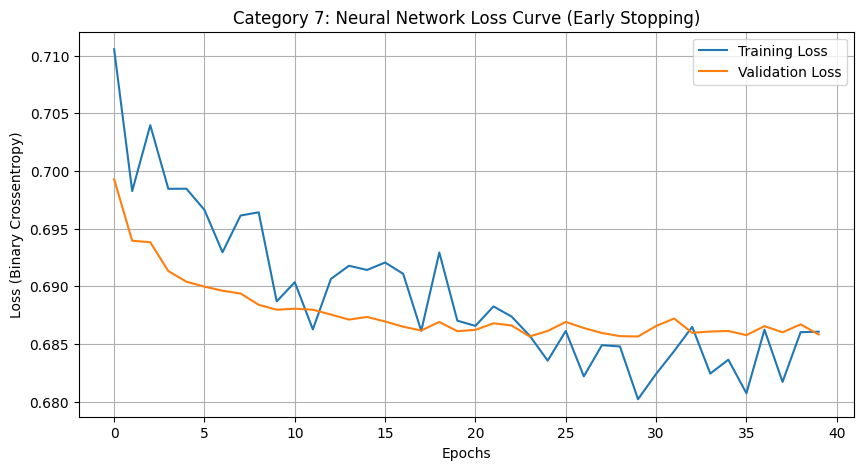

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define the Neural Network Architecture
nn_model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), # Dropout to combat overfitting
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid') # Binary probability output
])

# 2. Compile with Adam optimizer and binary crossentropy loss
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Define Early Stopping methodology using the Validation Set
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 4. Train the model (Monitoring Training vs. Validation Loss)
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val), # Used strictly for model tuning
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# 5. Evaluate strictly on the isolated Test set
test_loss, test_acc = nn_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Neural Network Test Set Accuracy: {round(test_acc, 4)}")

# 6. Plot the Training and Validation Loss (Illustration requirement)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Category 7: Neural Network Loss Curve (Early Stopping)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()


**Interpretation & Recommended Action:**
 The loss curve displays the training progression.
Using a separate validation fold to trigger early stopping allowed us to halt training before
the model began fitting noise. The final performance was evaluated on a clean test set.
Because neural networks function as black boxes, we advise setting strict stop-loss orders on
any live trades initiated by the model's predictions.